# Mini-Project: Advanced Statistical Analysis of Apple Inc. Stock Data
### AAPL — 1981 to 2023

In [1]:
import io, zipfile, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

URL = (
    "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/"
    "Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip"
)

try:
    r = requests.get(URL, timeout=30)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_name) as f:
            df = pd.read_csv(f)
    print("Loaded from URL.")
except Exception as e:
    print(f"URL failed ({e}). Falling back to local file.")
    df = pd.read_csv('AAPL.csv')

print(f"Shape: {df.shape}")
df.head()

Loaded from URL.
Shape: (10608, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


## 1. Data Loading and Exploration

In [40]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns:", df.columns.tolist())

# Parse date
date_col = [c for c in df.columns if 'date' in c][0]
df.rename(columns={date_col: 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)
df['year'] = df['date'].dt.year

print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Null Values ===")
print(df.isnull().sum())
print(f"\nDate range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Trading days: {len(df)}")

Columns: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

=== Data Types ===
date         datetime64[us]
open                float64
high                float64
low                 float64
close               float64
adj_close           float64
volume                int64
year                  int32
dtype: object

=== Null Values ===
date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
year         0
dtype: int64

Date range: 1981-01-02 → 2023-01-27
Trading days: 10608


In [3]:
# Identify numeric columns dynamically
close_col  = [c for c in df.columns if 'close' in c and 'adj' not in c][0]
open_col   = [c for c in df.columns if 'open'  in c][0]
high_col   = [c for c in df.columns if 'high'  in c][0]
low_col    = [c for c in df.columns if 'low'   in c][0]
vol_col    = [c for c in df.columns if 'volume' in c][0]

for col in [close_col, open_col, high_col, low_col, vol_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=[close_col], inplace=True)
print(f"Clean dataset: {len(df)} rows")
df[[close_col, open_col, high_col, low_col, vol_col]].describe().round(2)

Clean dataset: 10608 rows


,close,open,high,low,volume
count,10608.00,10608.00,10608.00,10608.00,1.060800e+04
mean,16.70,16.69,16.88,16.50,3.275098e+08
std,35.47,35.45,35.88,35.03,3.378203e+08
min,0.05,0.05,0.05,0.05,0.000000e+00
25%,0.29,0.29,0.30,0.28,1.213044e+08
50%,0.49,0.49,0.50,0.48,2.145976e+08
75%,16.27,16.32,16.42,16.15,4.066804e+08
max,182.01,182.63,182.94,179.12,7.421641e+09


## 2. Data Visualization

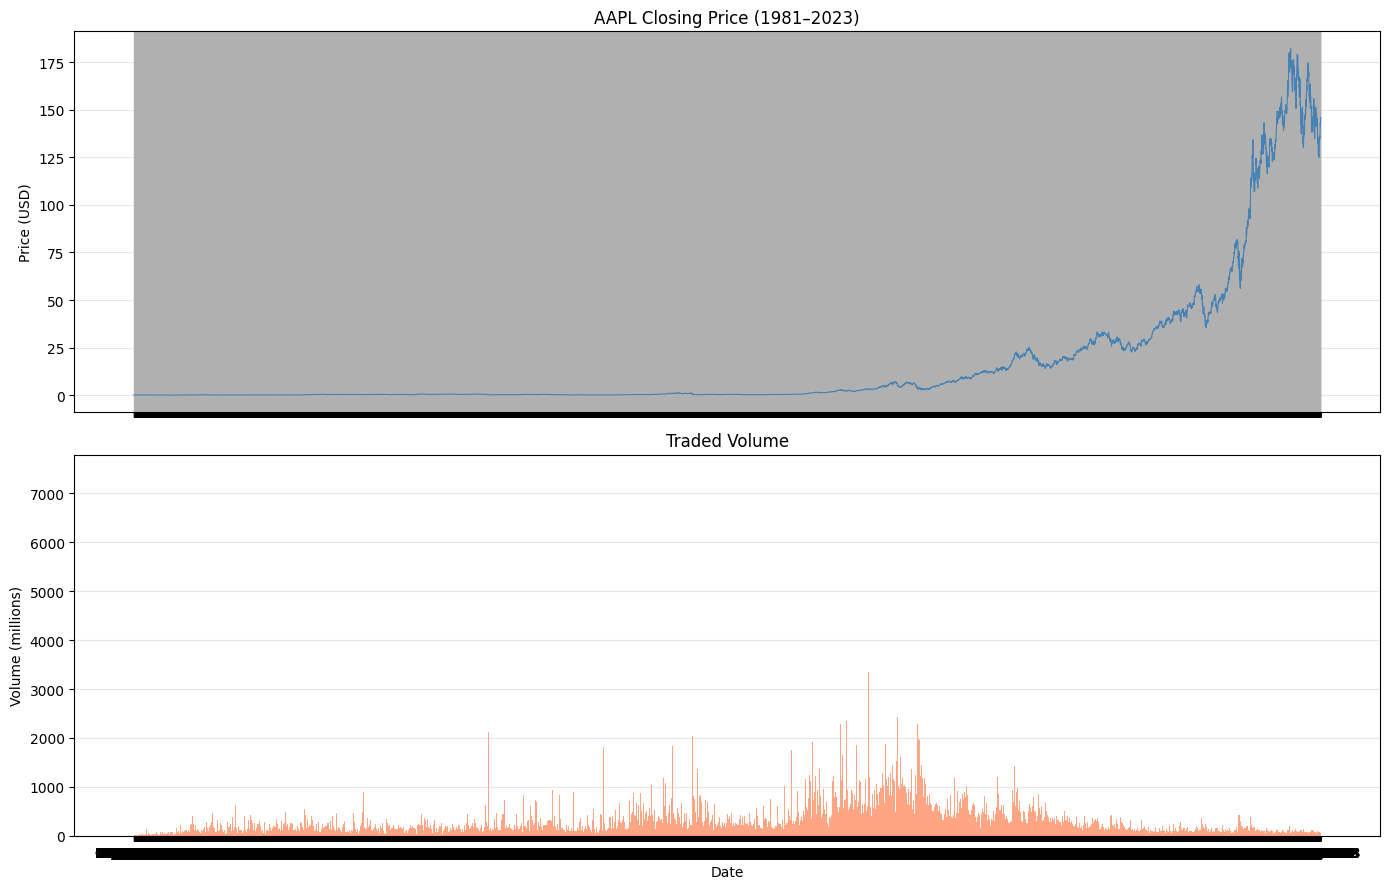

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Closing price
axes[0].plot(df['date'], df[close_col], color='steelblue', linewidth=0.8)
axes[0].set_title('AAPL Closing Price (1981–2023)')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df['date'], df[vol_col] / 1e6, color='coral', width=1, edgecolor='none', alpha=0.7)
axes[1].set_title('Traded Volume')
axes[1].set_ylabel('Volume (millions)')
axes[1].set_xlabel('Date')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Candlestick chart — last 60 trading days
candle = df.tail(60).copy()
candle['date'] = pd.to_datetime(df['date'], dayfirst=True)

fig, axe = plt.subplots(figsize=(12,6))


,date,open,high,low,close,adj_close,volume,year
10548,2022-11-01,155.080002,155.449997,149.130005,150.649994,150.400497,80379300,2022
10549,2022-11-02,148.949997,152.169998,145.000000,145.029999,144.789810,93604600,2022
10550,2022-11-03,142.059998,142.800003,138.750000,138.880005,138.650009,97918500,2022
10551,2022-11-04,142.089996,142.669998,134.380005,138.380005,138.380005,140814800,2022
10552,2022-11-07,137.110001,139.149994,135.669998,138.919998,138.919998,83374600,2022


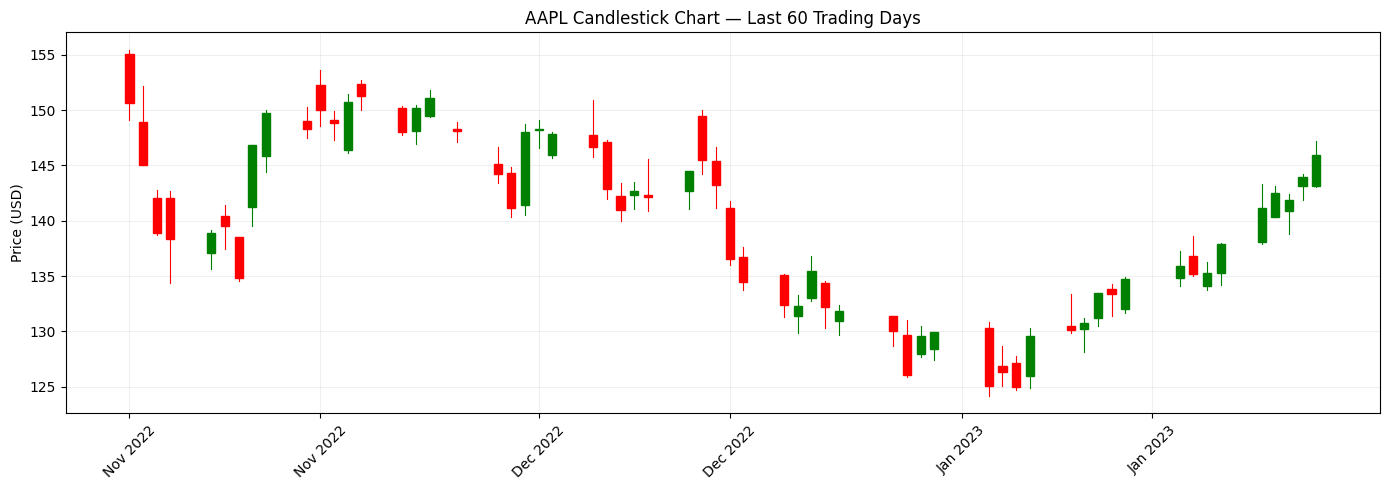

In [11]:
# Candlestick chart — last 60 trading days
candle = df.tail(60).copy()
candle['date'] = pd.to_datetime(candle['date'], dayfirst=True)

fig, ax = plt.subplots(figsize=(14, 5))

for _, row in candle.iterrows():
    color = 'green' if row[close_col] >= row[open_col] else 'red'
    # Wick
    ax.plot([row['date'], row['date']], [row[low_col], row[high_col]],
            color=color, linewidth=0.8)
    # Body
    body_bottom = min(row[open_col], row[close_col])
    body_height = abs(row[close_col] - row[open_col])
    rect = Rectangle(
        (mdates.date2num([row['date']])[0] - 0.3, body_bottom),
        0.6, max(body_height, 0.01),
        color=color, zorder=2
    )
    ax.add_patch(rect)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.set_title('AAPL Candlestick Chart — Last 60 Trading Days')
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Statistical Analysis

In [25]:
close = df[close_col].values

print("=== Summary Statistics for Closing Price ===")
print(f"Mean              : ${np.mean(close):.2f}")
print(f"Median            : ${np.median(close):.2f}")
print(f"Standard Deviation: ${np.std(close):.2f}")
print(f"Min               : ${np.min(close):.2f}")
print(f"Max               : ${np.max(close):.2f}")
print(f"Skewness          : {stats.skew(close):.4f}")
print(f"Kurtosis          : {stats.kurtosis(close):.4f}")

=== Summary Statistics for Closing Price ===
Mean              : $16.70
Median            : $0.49
Standard Deviation: $35.47
Min               : $0.05
Max               : $182.01
Skewness          : 2.8733
Kurtosis          : 7.7761


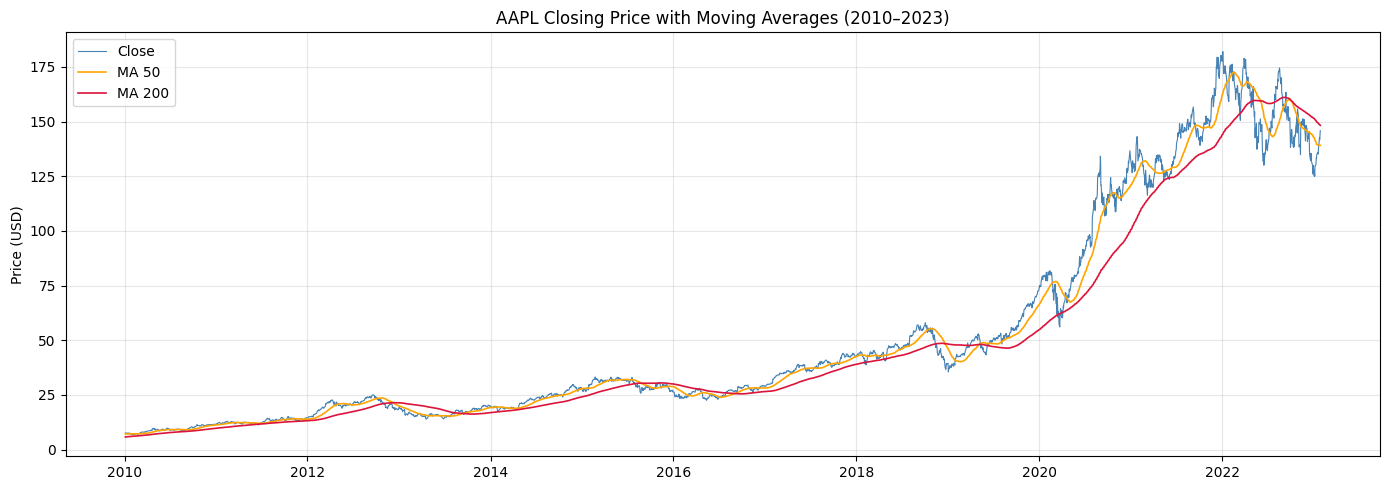

In [24]:
# Moving averages: 50-day and 200-day
df['ma50']  = df[close_col].rolling(50).mean()
df['ma200'] = df[close_col].rolling(200).mean()

# Focus on post-2010 for readability
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year'] = df['date'].dt.year
recent = df[df['year'] >= 2010]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent['date'], recent[close_col], color='steelblue', linewidth=0.8, label='Close')
ax.plot(recent['date'], recent['ma50'],    color='orange',    linewidth=1.2, label='MA 50')
ax.plot(recent['date'], recent['ma200'],   color='crimson',   linewidth=1.2, label='MA 200')
ax.set_title('AAPL Closing Price with Moving Averages (2010–2023)')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Hypothesis Testing

In [26]:
# T-test: compare mean closing price between two recent years
year_a, year_b = 2020, 2022
prices_a = df[df['year'] == year_a][close_col].values
prices_b = df[df['year'] == year_b][close_col].values

t_stat, p_value = stats.ttest_ind(prices_a, prices_b)

print(f"Year {year_a} — mean close: ${np.mean(prices_a):.2f}  (n={len(prices_a)})")
print(f"Year {year_b} — mean close: ${np.mean(prices_b):.2f}  (n={len(prices_b)})")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value    : {p_value:.6f}")

if p_value < 0.05:
    print(f"\nConclusion: The mean closing prices of {year_a} and {year_b} differ significantly (p < 0.05).")
else:
    print(f"\nConclusion: No significant difference in mean closing prices (p >= 0.05).")

Year 2020 — mean close: $95.35  (n=253)
Year 2022 — mean close: $154.84  (n=251)

t-statistic: -37.1157
p-value    : 0.000000

Conclusion: The mean closing prices of 2020 and 2022 differ significantly (p < 0.05).


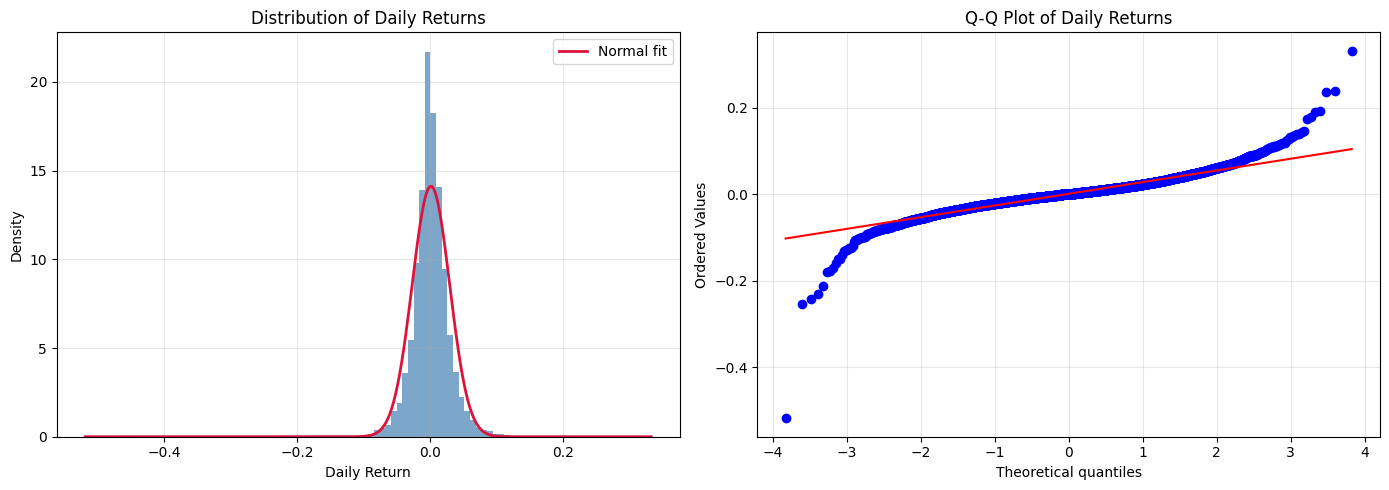

Normality test (D'Agostino-Pearson):
  statistic = 2719.2053,  p-value = 0.00e+00
  Daily returns are NOT normally distributed (heavy tails / fat tails typical of financial data).


In [27]:
# Daily returns and normality test
df['daily_return'] = df[close_col].pct_change()
returns = df['daily_return'].dropna().values

stat, p_norm = stats.normaltest(returns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(returns, bins=100, color='steelblue', edgecolor='none', density=True, alpha=0.7)
x = np.linspace(returns.min(), returns.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), color='crimson', linewidth=2, label='Normal fit')
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Normality test (D'Agostino-Pearson):")
print(f"  statistic = {stat:.4f},  p-value = {p_norm:.2e}")
if p_norm < 0.05:
    print("  Daily returns are NOT normally distributed (heavy tails / fat tails typical of financial data).")
else:
    print("  Daily returns appear normally distributed.")

## 5. Advanced Statistical Techniques (Bonus)

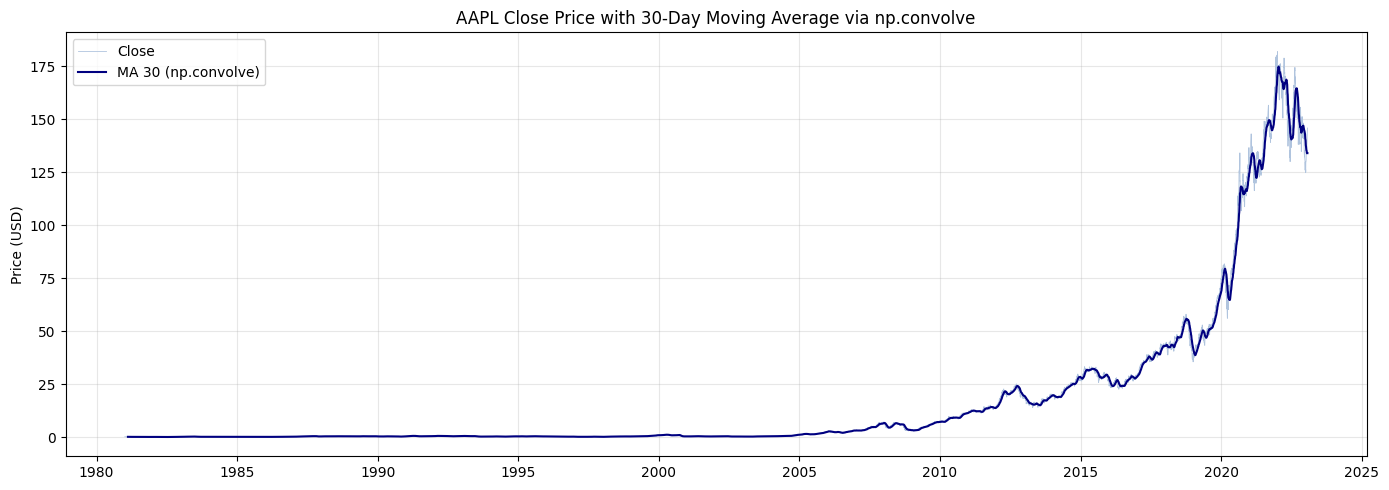

In [28]:
# --- Signal Processing: moving average via np.convolve ---
close_vals = df[close_col].values
window = 30
kernel = np.ones(window) / window
ma_conv = np.convolve(close_vals, kernel, mode='valid')

# Align dates
dates_conv = df['date'].values[window - 1:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], close_vals, color='lightsteelblue', linewidth=0.6, label='Close')
ax.plot(dates_conv, ma_conv, color='navy', linewidth=1.5, label=f'MA {window} (np.convolve)')
ax.set_title(f'AAPL Close Price with {window}-Day Moving Average via np.convolve')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Pearson correlation between MA(50) and Volume: -0.2156

The correlation is weak, suggesting price trend and volume move largely independently.


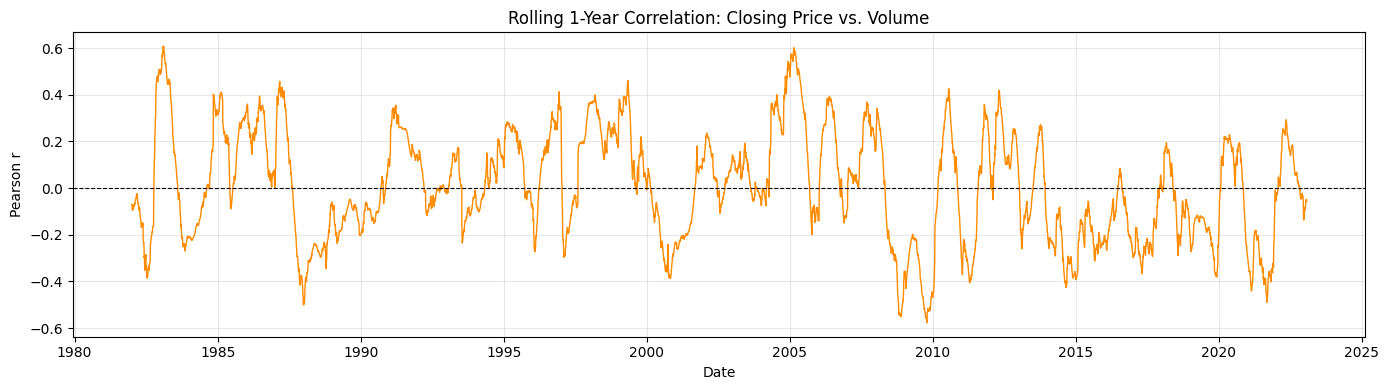

In [29]:
# --- np.corrcoef: correlation between MA(50) and Volume ---
corr_df = df[['ma50', vol_col]].dropna()
ma50_vals = corr_df['ma50'].values
vol_vals  = corr_df[vol_col].values

corr_matrix = np.corrcoef(ma50_vals, vol_vals)
correlation = corr_matrix[0, 1]

print(f"Pearson correlation between MA(50) and Volume: {correlation:.4f}")
print()
if abs(correlation) > 0.5:
    direction = 'positive' if correlation > 0 else 'negative'
    print(f"There is a strong {direction} correlation between the 50-day moving average of the closing price and trading volume.")
else:
    print("The correlation is weak, suggesting price trend and volume move largely independently.")

# Rolling 252-day (1 year) correlation
rolling_corr = df[close_col].rolling(252).corr(df[vol_col])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], rolling_corr, color='darkorange', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling 1-Year Correlation: Closing Price vs. Volume')
ax.set_ylabel('Pearson r')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary and Insights

In [30]:
yearly_close = df.groupby('year')[close_col].mean().round(2)
best_year  = yearly_close.idxmax()
worst_year = yearly_close.idxmin()

print("=" * 55)
print("         SUMMARY — AAPL STOCK ANALYSIS")
print("=" * 55)
print(f"Dataset period  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Trading days    : {len(df)}")
print()
print(f"All-time low close   : ${df[close_col].min():.2f}  ({df.loc[df[close_col].idxmin(), 'date'].date()})")
print(f"All-time high close  : ${df[close_col].max():.2f}  ({df.loc[df[close_col].idxmax(), 'date'].date()})")
print(f"Overall mean close   : ${np.mean(close):.2f}")
print(f"Overall median close : ${np.median(close):.2f}")
print()
print(f"Highest avg yearly close : {best_year}  (${yearly_close[best_year]:.2f})")
print(f"Lowest  avg yearly close : {worst_year}  (${yearly_close[worst_year]:.2f})")
print()
print(f"Mean daily return    : {np.mean(returns)*100:.4f}%")
print(f"Std daily return     : {np.std(returns)*100:.4f}%")
print(f"Daily returns normal : {'No (fat tails)' if p_norm < 0.05 else 'Yes'}")
print()
print("Key Insights:")
print("  - AAPL's price has grown exponentially, particularly after 2010.")
print("  - The MA(50)/MA(200) crossover is a classic trend-following signal.")
print("  - Daily returns exhibit fat tails — extreme moves occur more often")
print("    than a normal distribution would predict.")
print("  - The rolling price-volume correlation fluctuates over time, reflecting")
print("    changing market dynamics and investor behavior.")

         SUMMARY — AAPL STOCK ANALYSIS
Dataset period  : 1981-01-02 → 2023-01-27
Trading days    : 10608

All-time low close   : $0.05  (1982-07-08)
All-time high close  : $182.01  (2022-01-03)
Overall mean close   : $16.70
Overall median close : $0.49

Highest avg yearly close : 2022  ($154.84)
Lowest  avg yearly close : 1982  ($0.09)

Mean daily return    : 0.1052%
Std daily return     : 2.8234%
Daily returns normal : No (fat tails)

Key Insights:
  - AAPL's price has grown exponentially, particularly after 2010.
  - The MA(50)/MA(200) crossover is a classic trend-following signal.
  - Daily returns exhibit fat tails — extreme moves occur more often
    than a normal distribution would predict.
  - The rolling price-volume correlation fluctuates over time, reflecting
    changing market dynamics and investor behavior.


## 7. Reflection

**Challenges encountered:**

- **Column naming inconsistency**: the CSV file uses slightly different column names depending on the source. The solution was to normalize all column names to lowercase and detect the relevant columns dynamically using keyword matching, making the notebook robust to variations.

- **Candlestick chart without mplfinance**: building a candlestick chart using only Matplotlib's `Rectangle` patches required manually computing body height and aligning wicks, which is more verbose than a dedicated library but provides full control and no extra dependency.

- **Non-normal daily returns**: the normality test strongly rejects the normal distribution hypothesis. This is expected in financial data due to fat tails (extreme events). A future improvement would be to fit a Student-t or stable distribution to better model the return distribution.

- **Long time series (40+ years)**: visualizing the full price history compresses early data into near-zero values due to the exponential growth. Using a log scale on the y-axis or splitting the chart by era would improve readability.

**Key learnings:**

- `np.convolve` is a clean and efficient way to apply a moving average without looping.
- `np.corrcoef` gives a quick correlation matrix and pairs well with rolling Pandas correlation for time-varying analysis.
- SciPy's `stats.ttest_ind` and `stats.normaltest` integrate naturally with NumPy arrays and provide robust statistical tests with minimal code.